# Feature Importance Analysis

This notebook analyzes the feature importance of the final XGBoost model developed for AirShift.

The purpose of this analysis is to identify which input features the model relies on most when predicting future air quality deterioration.

The analysis uses the already trained final XGBoost model saved after the model development and final training stages. No additional model training or hyperparameter tuning is performed in this notebook.


## 1. Load Final Model

The final XGBoost model trained on the combined 2013–2015 training and validation data is loaded from the saved model file.

The model is used directly for feature importance analysis without any additional training or hyperparameter tuning.


In [7]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
MODEL_PATH = Path("../models/xgboost_final.joblib")

final_xgb = joblib.load(MODEL_PATH)

print("Final XGBoost model loaded successfully.")
print(f"Model path: {MODEL_PATH}")

Final XGBoost model loaded successfully.
Model path: ..\models\xgboost_final.joblib


### Model Fitting Verification

The loaded XGBoost model is checked to confirm that the estimator has been fitted successfully before extracting feature importance values.


In [3]:
is_fitted = hasattr(
    final_xgb.named_steps["model"],
    "n_features_in_"
)

print(f"XGBoost fitted: {is_fitted}")

XGBoost fitted: True


## 2. Extract Feature Importance

The XGBoost model provides built-in feature importance scores based on how features are used within the learned decision trees.

Because the final model uses a preprocessing pipeline, the feature names are first extracted from the fitted preprocessing step and then matched with the corresponding XGBoost importance values.

This ensures that each importance score is associated with the correct feature after preprocessing.


In [4]:
preprocessor = final_xgb.named_steps["preprocessor"]
xgb_model = final_xgb.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importance_values = xgb_model.feature_importances_

print("Number of feature names:", len(feature_names))
print("Number of importance values:", len(importance_values))

Number of feature names: 123
Number of importance values: 123


## 3. Feature Importance Table

A feature importance table is created by combining the processed feature names with their corresponding importance scores.

The features are sorted in descending order of importance so that the features most strongly relied upon by the model appear first.

The resulting table provides an overview of the relative importance of all transformed features used by the final XGBoost model.


In [6]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.insert(
    0,
    "Rank",
    range(1, len(feature_importance_df) + 1)
)

feature_importance_df.head(20)

,Rank,Feature,Importance
0,1,numerical__PM2.5_lag_1h,0.209936
1,2,categorical__wd_SW,0.029899
2,3,numerical__PM2.5,0.027127
3,4,categorical__wd_NNE,0.019024
4,5,categorical__wd_SSW,0.017747
5,6,categorical__wd_WSW,0.016778
6,7,numerical__PM10_lag_1h,0.016649
7,8,categorical__wd_N,0.016216
8,9,categorical__wd_NW,0.016107
9,10,numerical__RAIN,0.015902


## 4. Top 20 Feature Importance Visualization

The 20 features with the highest importance scores are visualized using a horizontal bar chart.

This visualization provides a clearer comparison of the relative importance of the most influential transformed features in the final XGBoost model.

The figure is saved in the project reports directory for use in the final project documentation.


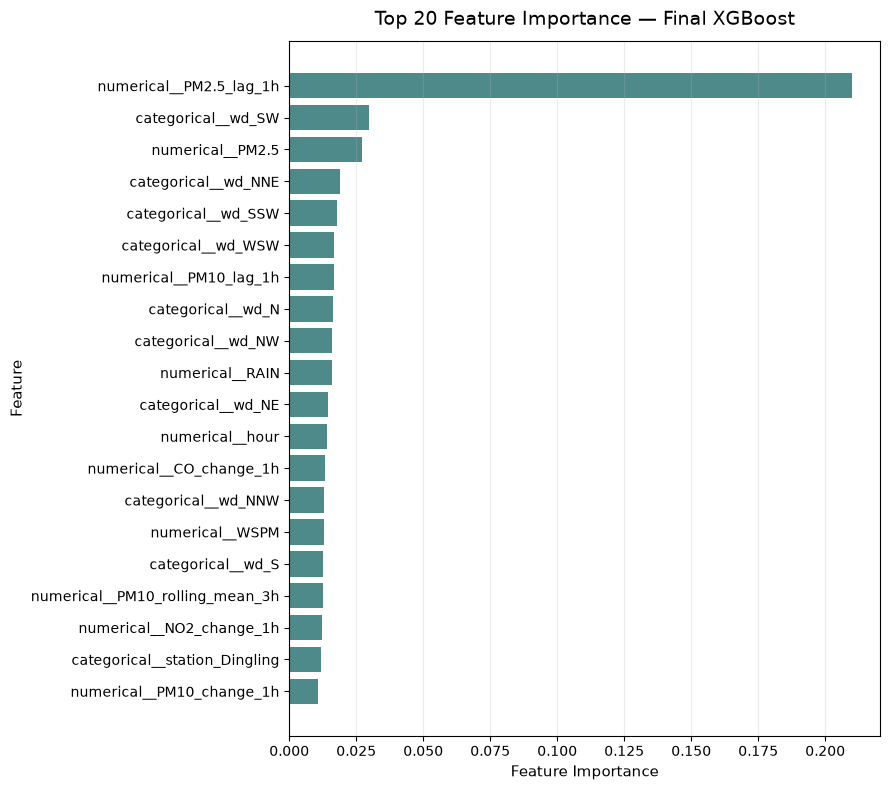

Figure saved to: ..\reports\figures\09_feature_importance\04_top_20_feature_importance.png


In [9]:
top_features = feature_importance_df.head(20).sort_values(
    by="Importance",
    ascending=True
)

FIGURES_DIR = Path("../reports/figures/09_feature_importance")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 8))

ax.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="#4F8A8B"
)

ax.set_title(
    "Top 20 Feature Importance — Final XGBoost",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Feature Importance", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

FIGURE_PATH = FIGURES_DIR / "04_top_20_feature_importance.png"

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {FIGURE_PATH}")

## 5. Feature Importance Findings

The feature importance analysis shows that recent air quality conditions are strongly represented in the final XGBoost model.

The most important feature is `PM2.5_lag_1h`, with an importance score of **0.2099**, substantially higher than the other features. The current `PM2.5` value also ranks highly, while several PM10-related features, including `PM10_lag_1h`, `PM10_rolling_mean_3h`, and `PM10_change_1h`, appear among the top 20 features.

Wind direction features are also prominent, with multiple `wd` categories appearing among the highest-ranked features. Meteorological and temporal variables such as `RAIN`, `WSPM`, and `hour`, as well as short-term pollutant changes such as `CO_change_1h` and `NO2_change_1h`, also contribute to the model.

Overall, the results indicate that the model relies mainly on **recent pollution conditions, short-term pollutant dynamics, wind direction, and meteorological information** when predicting deterioration events.

Feature importance indicates how the model uses these features, but it does not show the direction of their effects or establish causal relationships. These aspects will be investigated using SHAP analysis.


## 6. Interpretation Limitations

Feature importance shows how strongly features are used by the trained XGBoost model, but it does not explain the direction of their influence on individual predictions.

For example, a high importance score does not indicate whether higher or lower values of a feature increase the predicted probability of deterioration.

In addition, correlated features may share predictive information, which can affect their individual importance scores.

Therefore, feature importance is treated as an initial model interpretation step rather than a complete explanation of model behavior.
